In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from livelossplot import PlotLosses
import os
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"A utilizar: {device}")

A utilizar: cuda


## A Arquitetura do Modelo (LSTM-Autoencoder)

In [2]:
class Encoder(nn.Module):
    def __init__(self, n_features, embedding_dim=64):
        super(Encoder, self).__init__()
        self.n_features = n_features
        self.embedding_dim = embedding_dim
        
        # A camada LSTM que vai esmagar os dados
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=embedding_dim,
            num_layers=1,
            batch_first=True
        )

    def forward(self, x):
        # O x tem formato: (batch_size, seq_length, n_features)
        # O LSTM devolve a sequência inteira, mas nós só queremos o último estado oculto (a "memória" final da frase)
        _, (hidden_n, _) = self.lstm(x)
        
        # hidden_n tem formato (num_layers, batch, hidden_size). Removemos a dimensão extra.
        return hidden_n.squeeze(0)

class Decoder(nn.Module):
    def __init__(self, seq_len, embedding_dim=64, n_features=1):
        super(Decoder, self).__init__()
        self.seq_len = seq_len
        self.embedding_dim = embedding_dim
        self.n_features = n_features
        
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=embedding_dim,
            num_layers=1,
            batch_first=True
        )
        
        # A camada linear que converte a saída do LSTM de volta para as features originais (ex: velocidade, angulo)
        self.output_layer = nn.Linear(embedding_dim, n_features)

    def forward(self, x):
        # O Encoder enviou apenas um vetor por batch: (batch_size, embedding_dim)
        # Temos de repetir esta memória para o número de passos de tempo que queremos reconstruir
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        
        # Passar pelo LSTM
        x, _ = self.lstm(x)
        
        # Mapear de volta para o número original de features
        x = self.output_layer(x)
        return x

class LSTMAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = Encoder(n_features, embedding_dim)
        self.decoder = Decoder(seq_len, embedding_dim, n_features)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

## Preparação dos Dados (Sequências e Tensors) - Keyboard

In [3]:
# 1. Função para criar as sequências temporais (Janelas Deslizantes)
def create_sequences(dados_numpy, seq_length):
    xs = []
    # Desliza sobre os dados criando blocos de tamanho 'seq_length'
    for i in range(len(dados_numpy) - seq_length):
        xs.append(dados_numpy[i:(i + seq_length)])
    return np.array(xs)

In [4]:

# 1. Carregar o teu dataset perfeito do teclado
df_teclado = pd.read_csv('dataset/keystroke_dataset_processado.csv')

# 2. Selecionar APENAS as features matemáticas (Ignorar IDs e Labels)
colunas_ids = ['PARTICIPANT_ID', 'TEST_SECTION_ID']
features_teclado = ['PRESS_TIME', 'RELEASE_TIME',
    'DWELL_TIME', 'FLIGHT_TIME', 'OVERLAP_TIME', 
    'DIGRAPH_LATENCY', 'TRIGRAPH_LATENCY', 
    'IS_CORRECTION', 'IS_NAVIGATION', 
    'CTRL_BACKSPACE_PATTERN', 'ROLLING_WPM', 'RHYTHM_VARIANCE'
]

# Remover linhas com valores nulos (NaN) para não quebrar a rede neuronal
df_teclado = df_teclado.dropna(subset=features_teclado)

dados_brutos_features = df_teclado[features_teclado].values
dados_ids = df_teclado[colunas_ids].values

# 3. Normalizar
scaler_teclado = RobustScaler()
dados_escalados = scaler_teclado.fit_transform(dados_brutos_features)

# 4. A Abordagem PyTorch: Otimização Extrema de Memória
class KeystrokeSequenceDataset(Dataset):
    def __init__(self, features_data, ids_data, seq_len, step=15): 
        # Com step=15, a janela avança meia frase de cada vez. 
        # Isto reduz o tamanho do dataset em 15 vezes, sem perder contexto de aprendizagem!
        self.features = torch.tensor(features_data, dtype=torch.float32)
        self.ids = ids_data 
        self.seq_len = seq_len
        self.step = step
        
        # Pré-calcular os índices válidos dando "saltos"
        self.indices = list(range(0, len(self.features) - self.seq_len, self.step))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Vai buscar o índice real com base no salto
        real_idx = self.indices[idx]
        
        sequencia_x = self.features[real_idx : real_idx + self.seq_len]
        
        id_participante = self.ids[real_idx, 0]
        id_sessao = self.ids[real_idx, 1]

        return sequencia_x, sequencia_x, id_participante, id_sessao

# 5. Instanciar o Dataset e o DataLoader
SEQ_LEN_TECLADO = 30
BATCH_SIZE = 2048

dataset_pytorch = KeystrokeSequenceDataset(dados_escalados, dados_ids, SEQ_LEN_TECLADO)

tamanho_total = len(dataset_pytorch)
tamanho_treino = int(0.8 * tamanho_total)
tamanho_val = tamanho_total - tamanho_treino

# O PyTorch divide aleatoriamente de forma segura
dataset_treino, dataset_val = random_split(dataset_pytorch, [tamanho_treino, tamanho_val])

# O DataLoader do treino continua a baralhar (shuffle=True)
dataloader_treino = DataLoader(dataset_treino, batch_size=BATCH_SIZE, shuffle=True)

# O DataLoader da validação NÃO baralha (shuffle=False para avaliação consistente)
dataloader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total de sequências: {tamanho_total}")
print(f"Para Treino: {len(dataset_treino)} | Para Validação: {len(dataset_val)}")

Total de sequências: 2051628
Para Treino: 1641302 | Para Validação: 410326


## Preparação dos Dados (Sequências e Tensors) - Mouse

In [5]:
# --- Exemplo de como usar com o teu DataFrame ---
# Vamos imaginar que carregaste os dados normais (apenas is_illegal == 0)
df = pd.read_parquet('dataset/mouse_dataset_processado.parquet')
df_normal = df[df['is_illegal'] == 0].copy()

# Selecionar apenas as colunas matemáticas (excluir IDs e Labels)
colunas_ids_rato = ['USER_ID', 'SESSION_ID']
features = ['dt', 'dx', 'dy', 'distance', 'velocity', 'acceleration', 'angle', 'angle_change', 'curvature', 'is_idle', 'direction_bin', 'is_pressed', 'is_released', 'is_drag', 'is_overshoot']
dados_brutos_rato = df_normal[features].values
dados_ids_rato = df_normal[colunas_ids_rato].values

# 2. Normalizar os dados (Esmagar picos extremos de velocidade do rato)
scaler = RobustScaler()
dados_treino_escalados = scaler.fit_transform(dados_brutos_rato)

# Corta qualquer outlier matemático que tenha sobrevivido ao scaler para um máximo de 10.
# Isto previne o "Exploding Gradient" que paralisou a rede!
dados_treino_escalados = np.clip(dados_treino_escalados, -10.0, 10.0)

# 4. A Classe Dataset para o Rato
class MouseSequenceDataset(Dataset):
    def __init__(self, features_data, ids_data, seq_len, step=10): # <-- Adicionámos o Step=10
        self.features = torch.tensor(features_data, dtype=torch.float32)
        self.ids = ids_data 
        self.seq_len = seq_len
        self.step = step
        
        # Pré-calcular os índices válidos dando "saltos"
        self.indices = list(range(0, len(self.features) - self.seq_len, self.step))

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Vai buscar o índice real com base no salto
        real_idx = self.indices[idx]
        
        sequencia_x = self.features[real_idx : real_idx + self.seq_len]
        
        id_user = self.ids[real_idx, 0]
        id_sessao = self.ids[real_idx, 1]

        return sequencia_x, sequencia_x, id_user, id_sessao

# 5. Instanciar o Dataset e o DataLoader
SEQ_LEN_RATO = 120 # O rato precisa de mais eventos para formar um "gesto" completo
BATCH_SIZE = 1024

dataset_rato = MouseSequenceDataset(dados_treino_escalados, dados_ids_rato, SEQ_LEN_RATO)

# 5. DIVISÃO 80/20 (Treino vs Validação)
tamanho_total = len(dataset_rato)
tamanho_treino = int(0.8 * tamanho_total)
tamanho_val = tamanho_total - tamanho_treino

dataset_treino_rato, dataset_val_rato = random_split(dataset_rato, [tamanho_treino, tamanho_val])

dataloader_treino_rato = DataLoader(dataset_rato, batch_size=BATCH_SIZE, shuffle=True)
dataloader_val_rato = DataLoader(dataset_val_rato, batch_size=BATCH_SIZE, shuffle=False)

## Treino

In [6]:
def treinar_autoencoder(modelo, dataloader_treino, dataloader_val=None, epochs=50, learning_rate=0.001, checkpoint_dir='checkpoints'):
    
    # Criar a pasta de checkpoints se não existir
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    modelo = modelo.to(device)
    print(f"A treinar no dispositivo: {device}")
    
    # Critério (Erro Médio Quadrático) e Optimizador (Adam)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(modelo.parameters(), lr=learning_rate)
    
    liveloss = PlotLosses()
    
    historico_loss_treino = []
    historico_loss_val = []

    # O ciclo de treino
    for epoch in range(epochs):
        logs = {}
        
        modelo.train()
        loss_treino = 0
        
        # O dataloader agora devolve 4 variáveis. 
        # Nós usamos as duas primeiras para treinar e ignoramos os IDs.
        for batch_x, batch_y, batch_participantes, batch_sessoes in dataloader_treino:
            
            # Enviar apenas a matemática para a placa gráfica
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            # 1. Resetar os gradientes
            optimizer.zero_grad()
            
            # 2. Forward pass (O modelo tenta reconstruir os dados cego aos IDs)
            reconstrucao = modelo(batch_x)
            
            # 3. Calcular o erro (MSE)
            loss = criterion(reconstrucao, batch_y)
            
            # 4. Backward pass e atualizar os pesos
            loss.backward()
            optimizer.step()
            
            loss_treino += loss.item()
            
        loss_media_treino = loss_treino / len(dataloader_treino)
        historico_loss_treino.append(loss_media_treino)
        
        # Guardar a métrica de treino no dicionário (a chave tem de se chamar 'loss')
        logs['loss'] = loss_media_treino

        loss_media_val = 0
        if dataloader_val is not None:
            modelo.eval() # Modo de avaliação (desliga os gradientes, poupa RAM e previne aprendizagem)
            loss_val = 0
            
            with torch.no_grad(): 
                for batch_x, batch_y, _, _ in dataloader_val:
                    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                    
                    reconstrucao = modelo(batch_x)
                    loss = criterion(reconstrucao, batch_y)
                    loss_val += loss.item()
                    
            loss_media_val = loss_val / len(dataloader_val)
            historico_loss_val.append(loss_media_val)
            
            # Guardar a métrica de validação (a chave tem de se chamar 'val_loss')
            logs['val_loss'] = loss_media_val
            
        # --- GUARDAR CHECKPOINT (De 5 em 5 épocas) ---
        if (epoch + 1) % 5 == 0:
            checkpoint_path = os.path.join(checkpoint_dir, f'modelo_epoch_{epoch+1}.pth')
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': modelo.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss_media_treino,
            }, checkpoint_path)
            print(f" -> Checkpoint guardado: {checkpoint_path}")

        liveloss.update(logs)
        liveloss.send()
            
    return modelo

## Ciclo de Treino (Training Loop) - Keyboard

In [7]:
# Contar quantas features temos automaticamente (serão 10)
num_features_teclado = dados_escalados.shape[1]

# Criar o Cérebro do Teclado
modelo_teclado = LSTMAutoencoder(
    seq_len=SEQ_LEN_TECLADO, 
    n_features=num_features_teclado, 
    embedding_dim=64 # Como há 10 features, 64 neurónios de memória latente é ótimo
)

#### SALTAR A FRENTE ESTA CELULA SE JÁ TIVER O MODELO

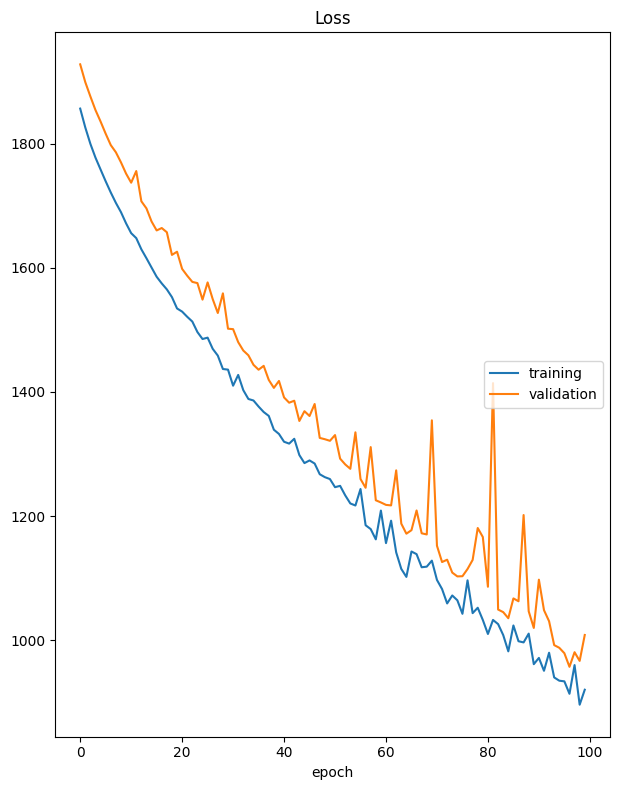

Loss
	training         	 (min:  896.306, max: 1856.259, cur:  920.416)
	validation       	 (min:  957.330, max: 1927.519, cur: 1008.606)


In [8]:
print("A treinar o perfil de teclado do Dono...")
# Usamos a mesma função treinar_autoencoder da mensagem anterior!

modelo_treinado_teclado = treinar_autoencoder(modelo_teclado, dataloader_treino, dataloader_val=dataloader_val, epochs=100, learning_rate=0.001)
torch.save(modelo_treinado_teclado.state_dict(), 'modelo_teclado_global.pth')

## Validação do modelo do teclado

Modelo do Teclado carregado com sucesso. A iniciar métricas globais...

--- RESULTADOS GLOBAIS DE VALIDAÇÃO (TECLADO) ---
MSE Médio (Erro Quadrático): 987.9702
MAE Médio (Erro Absoluto):   1.6771


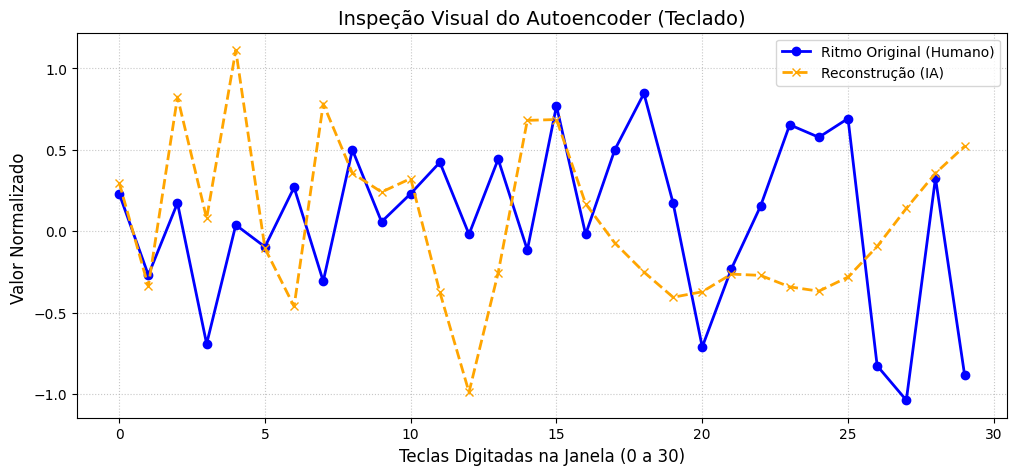

In [ ]:
# 1. Carregar a estrutura do modelo
num_features_teclado = dados_escalados.shape[1] 
modelo_teclado = LSTMAutoencoder(seq_len=SEQ_LEN_TECLADO, n_features=num_features_teclado, embedding_dim=64)

# Carregar o checkpoint de ouro do teclado
# ATENÇÃO: Substitui '30' pela época onde tiveste o menor val_loss no gráfico do teclado!
checkpoint_teclado = torch.load('checkpoints_teclado/modelo_epoch_95.pth', weights_only=False)
modelo_teclado.load_state_dict(checkpoint_teclado['model_state_dict'])

modelo_teclado = modelo_teclado.to(device)
modelo_teclado.eval() # Modo de avaliação para trancar os pesos

print("Modelo do Teclado carregado com sucesso. A iniciar métricas globais...")

# 2. Calcular Erros Globais no Validation Set
criterion_mse = nn.MSELoss()
criterion_mae = nn.L1Loss() # Erro Absoluto Médio

total_mse_tec = 0
total_mae_tec = 0

with torch.no_grad():
    for batch_x, batch_y, _, _ in dataloader_val:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        reconstrucao = modelo_teclado(batch_x)
        
        total_mse_tec += criterion_mse(reconstrucao, batch_y).item()
        total_mae_tec += criterion_mae(reconstrucao, batch_y).item()

avg_mse_tec = total_mse_tec / len(dataloader_val)
avg_mae_tec = total_mae_tec / len(dataloader_val)

print(f"\n--- RESULTADOS GLOBAIS DE VALIDAÇÃO (TECLADO) ---")
print(f"MSE Médio (Erro Quadrático): {avg_mse_tec:.4f}")
print(f"MAE Médio (Erro Absoluto):   {avg_mae_tec:.4f}")


# 3. Inspeção Visual (A Prova dos 9)
# Extrair 1 sequência (30 teclas) do validation set
um_batch_x_tec, _, _, _ = next(iter(dataloader_val))
uma_sequencia_tec = um_batch_x_tec[10:11].to(device)

with torch.no_grad():
    reconstrucao_seq_tec = modelo_teclado(uma_sequencia_tec)

# Passar para Numpy para desenhar
original_np_tec = uma_sequencia_tec.squeeze().cpu().numpy()
reconstrucao_np_tec = reconstrucao_seq_tec.squeeze().cpu().numpy()

# ESCOLHE A FEATURE A DESENHAR:
# Na nossa lista: ['DWELL_TIME', 'FLIGHT_TIME', 'OVERLAP_TIME', ...]
# O índice 1 é o FLIGHT_TIME (Tempo de Voo entre teclas), que é a assinatura mais forte de um utilizador!
FEATURE_IDX_TEC = 2 

plt.figure(figsize=(12, 5))
# Adicionamos 'marker="o"' para vermos cada tecla individualmente!
plt.plot(original_np_tec[:, FEATURE_IDX_TEC], label='Ritmo Original (Humano)', color='blue', linewidth=2, marker='o')
plt.plot(reconstrucao_np_tec[:, FEATURE_IDX_TEC], label='Reconstrução (IA)', color='orange', linestyle='dashed', linewidth=2, marker='x')

plt.title('Inspeção Visual do Autoencoder (Teclado)', fontsize=14)
plt.xlabel('Teclas Digitadas na Janela (0 a 30)', fontsize=12)
plt.ylabel('Valor Normalizado ', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## Ciclo de Treino (Training Loop) - Mouse

In [10]:
# --- Como invocar o treino ---
n_features = dados_treino_escalados.shape[1]
modelo_rato = LSTMAutoencoder(seq_len=SEQ_LEN_RATO, n_features=n_features, embedding_dim=64)

#### SALTAR ESTA CÉLULA A FRENTE SE JÁ TIVER O MODELO

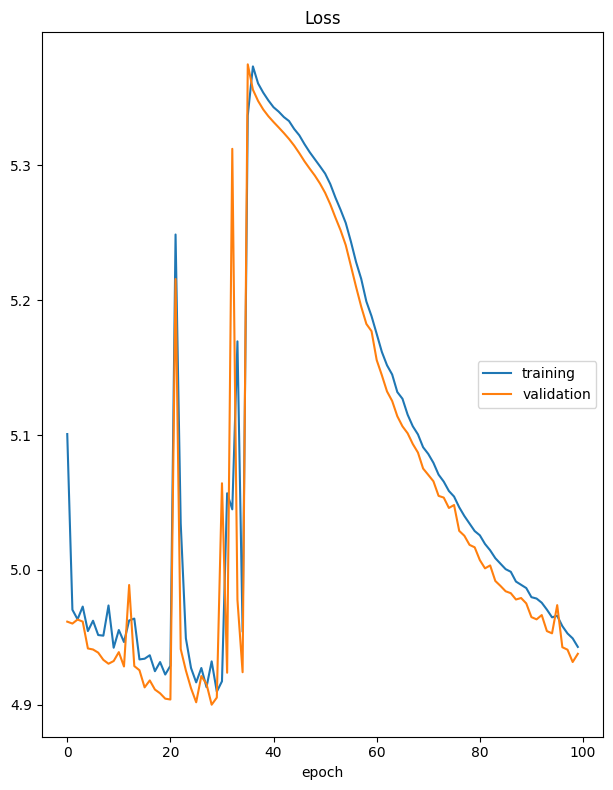

Loss
	training         	 (min:    4.910, max:    5.373, cur:    4.943)
	validation       	 (min:    4.900, max:    5.375, cur:    4.938)
Modelo guardado com sucesso!


In [27]:
print("A iniciar o treino do Autoencoder...")
modelo_rato_treinado = treinar_autoencoder(modelo_rato, dataloader_treino_rato, dataloader_val=dataloader_val_rato, epochs=100, learning_rate=0.001)
torch.save(modelo_rato_treinado.state_dict(), 'modelo_rato_global.pth')
print("Modelo guardado com sucesso!")

## Validação do modelo do rato

Modelo carregado com sucesso. A iniciar métricas globais...

--- RESULTADOS GLOBAIS DE VALIDAÇÃO ---
MSE Médio (Erro Quadrático): 4.9732
MAE Médio (Erro Absoluto):   1.0080


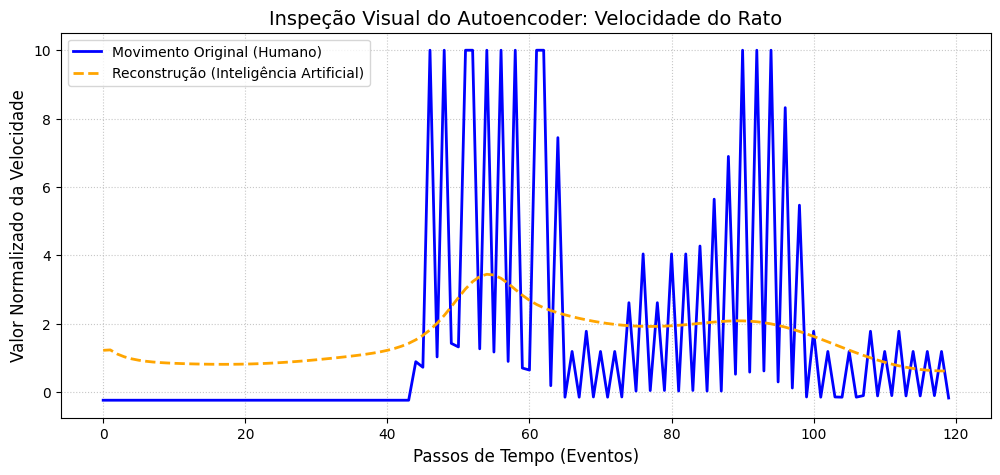

In [11]:
# 1. Carregar a estrutura do modelo
# Nota: Confirma se o teu embedding_dim do rato estava a 32 ou 64. No teu código anterior estava 32.
n_features = dados_treino_escalados.shape[1]
modelo_rato = LSTMAutoencoder(seq_len=SEQ_LEN_RATO, n_features=n_features, embedding_dim=32)

# Carregar os pesos da época de ouro (ajusta o nome do ficheiro para a época exata que escolheste)
checkpoint = torch.load('checkpoints_rato/modelo_epoch_25.pth', weights_only=False)
modelo_rato.load_state_dict(checkpoint['model_state_dict'])

modelo_rato = modelo_rato.to(device)
modelo_rato.eval() # Modo de avaliação (MUITO IMPORTANTE para não alterar os pesos)

print("Modelo carregado com sucesso. A iniciar métricas globais...")

# 2. Calcular Erros Globais no Validation Set
criterion_mse = nn.MSELoss()
criterion_mae = nn.L1Loss() # Erro Absoluto Médio

total_mse = 0
total_mae = 0

with torch.no_grad():
    for batch_x, batch_y, _, _ in dataloader_val_rato:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        reconstrucao = modelo_rato(batch_x)
        
        total_mse += criterion_mse(reconstrucao, batch_y).item()
        total_mae += criterion_mae(reconstrucao, batch_y).item()

avg_mse = total_mse / len(dataloader_val_rato)
avg_mae = total_mae / len(dataloader_val_rato)

print(f"\n--- RESULTADOS GLOBAIS DE VALIDAÇÃO ---")
print(f"MSE Médio (Erro Quadrático): {avg_mse:.4f}")
print(f"MAE Médio (Erro Absoluto):   {avg_mae:.4f}")


# 3. Inspeção Visual (A Prova dos 9)
# Vamos extrair apenas 1 sequência (120 eventos) do validation set
um_batch_x, _, _, _ = next(iter(dataloader_val_rato))
uma_sequencia = um_batch_x[0:1].to(device) 

with torch.no_grad():
    reconstrucao_seq = modelo_rato(uma_sequencia)

# Converter de tensores de volta para arrays numpy (CPU) para desenhar
original_np = uma_sequencia.squeeze().cpu().numpy()
reconstrucao_np = reconstrucao_seq.squeeze().cpu().numpy()

# ESCOLHE A FEATURE A DESENHAR:
# Olha para a tua lista de features: ['dt', 'dx', 'dy', 'distance', 'velocity', 'acceleration', ...]
# O índice 4 corresponde à 'velocity' (0=dt, 1=dx, 2=dy, 3=distance, 4=velocity).
FEATURE_IDX = 4 

plt.figure(figsize=(12, 5))
plt.plot(original_np[:, FEATURE_IDX], label='Movimento Original (Humano)', color='blue', linewidth=2)
plt.plot(reconstrucao_np[:, FEATURE_IDX], label='Reconstrução (Inteligência Artificial)', color='orange', linestyle='dashed', linewidth=2)

plt.title('Inspeção Visual do Autoencoder: Velocidade do Rato', fontsize=14)
plt.xlabel('Passos de Tempo (Eventos)', fontsize=12)
plt.ylabel('Valor Normalizado da Velocidade', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## O Fine-Tuning (Transfer Learning para o Dono) - Keyboard

In [12]:
print(df_teclado['PARTICIPANT_ID'].unique())

[209489. 335249. 509735. ...  34501.  89411.  86085.]


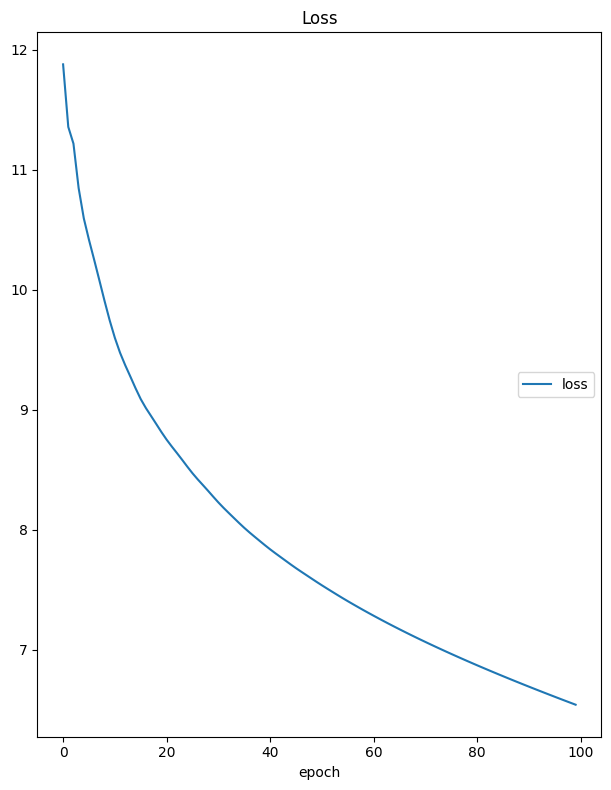

Loss
	loss             	 (min:    6.542, max:   11.879, cur:    6.542)
Modelo do Dono calibrado e guardado!


In [ ]:
# 1. Simulação: O Funcionario novo chegou (ex: O Utilizador com ID 5)
df_dono = df_teclado[df_teclado['PARTICIPANT_ID'] == 209489].copy()

# Separar IDs e Matemática
dados_brutos_dono = df_dono[features_teclado].values
dados_ids_dono = df_dono[colunas_ids].values

# 2. Normalizar usando o MESMO scaler global treinado anteriormente!
# ATENÇÃO: Usar .transform() e NUNCA .fit_transform() nesta fase.
dados_escalados_dono = scaler_teclado.transform(dados_brutos_dono)

# 3. Criar o Dataset e DataLoader do Dono
dataset_dono = KeystrokeSequenceDataset(dados_escalados_dono, dados_ids_dono, SEQ_LEN_TECLADO)

# --- DIVISÃO 70/30 PARA TESTE FALSO POSITIVOS E NEGATIVOS ---
tamanho_dono_total = len(dataset_dono)
tamanho_dono_treino = int(0.7 * tamanho_dono_total)
tamanho_dono_teste = tamanho_dono_total - tamanho_dono_treino

dataset_dono_treino, dataset_dono_teste = random_split(dataset_dono, [tamanho_dono_treino, tamanho_dono_teste])

# 4. Criar os dois DataLoaders independentes
# Este é APENAS para Fine-Tuning e Limiar
dataloader_dono_treino = DataLoader(dataset_dono_treino, batch_size=64, shuffle=True)

# Este é o "Cofre Fechado" APENAS para testar Falsos Positivos no final
dataloader_dono_teste = DataLoader(dataset_dono_teste, batch_size=64, shuffle=False)

# 4. Carregar o Modelo Global
checkpoint_teclado = torch.load('checkpoints_teclado/modelo_epoch_95.pth', weights_only=False)

# Extrair apenas os pesos do modelo e injetar no cérebro
modelo_teclado.load_state_dict(checkpoint_teclado['model_state_dict'])

print("A iniciar o Fine-Tuning para o perfil do Dono ...")
# O SEGREDO DO TRANSFER LEARNING: learning_rate muito baixo e poucas epochs
modelo_teclado_dono = treinar_autoencoder(
    modelo_teclado, 
    dataloader_dono_treino, 
    epochs=100, 
    learning_rate=0.0001
)

# Guardar o modelo específico deste utilizador
torch.save(modelo_teclado_dono.state_dict(), 'modelo_teclado_dono.pth')
print("Modelo do Dono calibrado e guardado!")

## O Fine-Tuning (Transfer Learning para o Dono) - Rato

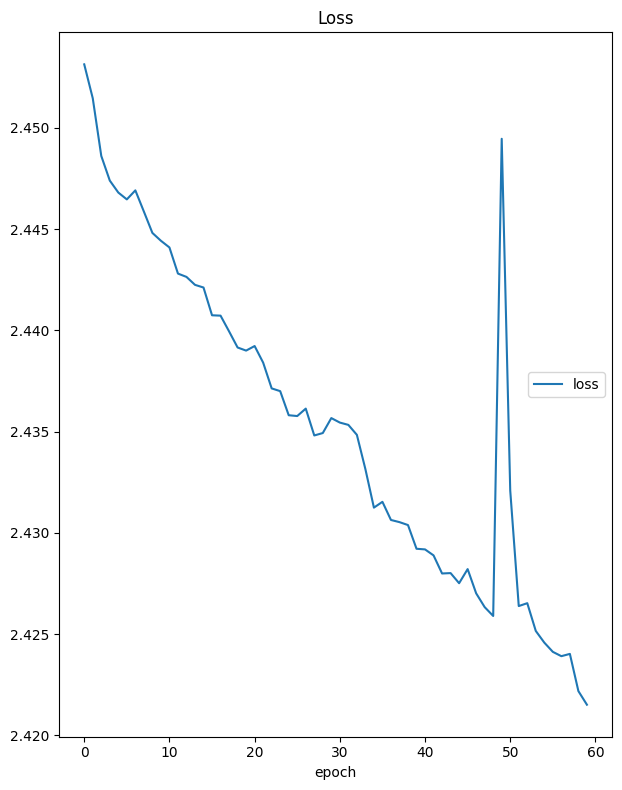

Loss
	loss             	 (min:    2.422, max:    2.453, cur:    2.422)
Modelo do Dono guardado com sucesso!


In [58]:
# 1. Isolar os dados normais (is_illegal == 0) apenas do Dono (Ex: User '7')
# NOTA: No dataset do rato, o USER_ID costuma ser lido como string ou inteiro, vamos testar como int/string
df_dono_rato = df_normal[(df_normal['USER_ID'].astype(str) == '7') & (df_normal['is_illegal'] == 0)].copy()

dados_brutos_dono_rato = df_dono_rato[features].values
dados_ids_dono_rato = df_dono_rato[colunas_ids_rato].values

# 2. Normalizar e Cortar com o MESMO scaler do Treino Global!
dados_escalados_dono_rato = scaler.transform(dados_brutos_dono_rato)
dados_escalados_dono_rato = np.clip(dados_escalados_dono_rato, -10.0, 10.0)

# 3. Criar Dataset e DataLoader
dataset_dono_rato = MouseSequenceDataset(dados_escalados_dono_rato, dados_ids_dono_rato, SEQ_LEN_RATO, step=10)

# --- DIVISÃO 70/30 PARA TESTE DE FALSOS POSITIVOS ---
tamanho_dono_total = len(dataset_dono_rato)
tamanho_dono_treino = int(0.7 * tamanho_dono_total)
tamanho_dono_teste = tamanho_dono_total - tamanho_dono_treino

dataset_dono_treino_rato, dataset_dono_teste_rato = random_split(dataset_dono_rato, [tamanho_dono_treino, tamanho_dono_teste])

dataloader_dono_rato_treino = DataLoader(dataset_dono_treino_rato, batch_size=128, shuffle=True)
dataloader_dono_rato_teste = DataLoader(dataset_dono_teste_rato, batch_size=64, shuffle=False)

checkpoint = torch.load('checkpoints_rato/modelo_epoch_25.pth', weights_only=False)
modelo_rato.load_state_dict(checkpoint['model_state_dict'])

# 4. Afinar o Modelo (Poucas épocas, Learning Rate baixinho)
print("A calibrar a cinemática fina para o User 7...")
modelo_rato_dono = treinar_autoencoder(
    modelo_rato, # Passamos o modelo já treinado!
    dataloader_dono_rato_treino, 
    epochs=60, 
    learning_rate=0.0001 # 10x mais pequeno para não esquecer o global
)

torch.save(modelo_rato_dono.state_dict(), 'modelo_rato_dono_user7.pth')
print("Modelo do Dono guardado com sucesso!")

## O Ponto Crítico - Como detetar o Intruso? (Inscrição e Limiar)

In [15]:
def calcular_limiar_anomalia(modelo, dataloader):
    device = next(modelo.parameters()).device
    modelo.eval() # Modo de avaliação (desliga os gradientes)
    
    todos_erros = []
    
    with torch.no_grad():
        # Avaliar lote a lote para não estourar a memória
        for batch_x, _, _, _ in dataloader:
            batch_x = batch_x.to(device)
            
            reconstrucao = modelo(batch_x)
            
            # Calcular o Erro Quadrático Médio (MSE) por sequência (dim=1 e 2)
            mse_batch = torch.mean(torch.pow(reconstrucao - batch_x, 2), dim=[1, 2])
            
            # Guardar os erros desta iteração na lista global
            todos_erros.extend(mse_batch.cpu().numpy())
    
    # A ESTATÍSTICA DO BLOQUEIO:
    erro_medio = np.mean(todos_erros)
    desvio_padrao = np.std(todos_erros)
    
    # Threshold seguro: Média + 2x Desvio Padrão
    threshold_seguro = erro_medio + (2 * desvio_padrao)
    
    return threshold_seguro, erro_medio

# Teclado

In [16]:
# --- 1. Definir a Baseline de Segurança do Dono ---
# (Passamos o dataloader do dono criado no bloco anterior)
limiar_bloqueio, erro_medio_dono = calcular_limiar_anomalia(modelo_teclado_dono, dataloader_dono_treino)
print(f"Erro Base do Dono: {erro_medio_dono:.4f} | Threshold de Alarme: {limiar_bloqueio:.4f}")

# --- 2. SIMULAÇÃO DE INTRUSO (Inferência em Tempo Real) ---
# O utilizador 9 senta-se ao computador do utilizador 5
df_intruso = df_teclado[df_teclado['PARTICIPANT_ID'] == 335249].copy()

dados_brutos_intruso = df_intruso[features_teclado].values
dados_ids_intruso = df_intruso[colunas_ids].values

# Transformar e empacotar os dados do intruso
dados_escalados_intruso = scaler_teclado.transform(dados_brutos_intruso)
dataset_intruso = KeystrokeSequenceDataset(dados_escalados_intruso, dados_ids_intruso, SEQ_LEN_TECLADO)

# Para inferência em tempo real, batch_size=1 (avaliamos 1 sequência de cada vez)
dataloader_intruso = DataLoader(dataset_intruso, batch_size=1, shuffle=False)

# O sistema avalia a primeira sequência (30 teclas) que o intruso digitou
modelo_teclado_dono.eval()
with torch.no_grad():
    # Extrair apenas o primeiro batch (1 sequência de 30 teclas)
    primeira_sequencia_x, _, id_participante, id_sessao = next(iter(dataloader_intruso))
    primeira_sequencia_x = primeira_sequencia_x.to(device)
    
    reconstrucao_intruso = modelo_teclado_dono(primeira_sequencia_x)
    erro_intruso = torch.mean(torch.pow(reconstrucao_intruso - primeira_sequencia_x, 2)).item()

print(f"\n--- TESTE DE SEGURANÇA ---")
print(f"Utilizador atual no teclado: ID {id_participante[0].item()}")
print(f"Erro gerado pelas teclas: {erro_intruso:.4f}")

if erro_intruso > limiar_bloqueio:
    print("🚨 ANOMALIA DETETADA: Cadência de digitação incompatível. BLOQUEANDO SESSÃO! 🚨")
else:
    print("✅ Identidade confirmada. Sessão continua.")

Erro Base do Dono: 6.5256 | Threshold de Alarme: 23.2825

--- TESTE DE SEGURANÇA ---
Utilizador atual no teclado: ID 335249.0
Erro gerado pelas teclas: 46.8056
🚨 ANOMALIA DETETADA: Cadência de digitação incompatível. BLOQUEANDO SESSÃO! 🚨


## Avaliação Global de Segurança - Teclado

In [17]:
# 1. Recuperar o limiar do Dono (ID 5)
limiar_bloqueio, erro_medio_dono = calcular_limiar_anomalia(modelo_teclado_dono, dataloader_dono_treino)
print(f"Limiar de Bloqueio do Dono: {limiar_bloqueio:.4f}")

# 2. Isolar TODOS OS INTRUSOS (Qualquer pessoa que não seja o ID 5)
id_dono_teclado = 5
df_todos_intrusos = df_teclado[df_teclado['PARTICIPANT_ID'] != id_dono_teclado].copy()

print(f"A preparar {len(df_todos_intrusos)} eventos de intrusos para o teste de stress...")

dados_brutos_intrusos = df_todos_intrusos[features_teclado].values
dados_ids_intrusos = df_todos_intrusos[colunas_ids].values

# Normalizar com o Scaler Global
dados_escalados_intrusos = scaler_teclado.transform(dados_brutos_intrusos)

# Criar o Dataset e DataLoader (Usamos um batch grande para avaliar muito rápido!)
dataset_intrusos = KeystrokeSequenceDataset(dados_escalados_intrusos, dados_ids_intrusos, SEQ_LEN_TECLADO, step=15)
dataloader_intrusos = DataLoader(dataset_intrusos, batch_size=512, shuffle=False)

# 3. MÁQUINA DE INFERÊNCIA GLOBAL
total_sequencias_testadas = 0
intrusos_bloqueados = 0

modelo_teclado_dono.eval()
with torch.no_grad():
    for batch_x, _, _, _ in dataloader_intrusos:
        batch_x = batch_x.to(device)
        
        reconstrucao = modelo_teclado_dono(batch_x)
        
        # Calcular o Erro (MSE) para cada sequência individual dentro do lote
        mse_batch = torch.mean(torch.pow(reconstrucao - batch_x, 2), dim=[1, 2])
        
        # Contar quantas sequências neste lote ultrapassaram o threshold
        bloqueios_neste_lote = torch.sum(mse_batch > limiar_bloqueio).item()
        
        intrusos_bloqueados += bloqueios_neste_lote
        total_sequencias_testadas += len(batch_x)

# 4. OS RESULTADOS DA TESE
taxa_sucesso = (intrusos_bloqueados / total_sequencias_testadas) * 100

print(f"\n--- RESULTADOS DO SISTEMA DE DEFESA (TECLADO) ---")
print(f"Total de Ataques (Sequências) Simulados: {total_sequencias_testadas}")
print(f"Ataques Travados pelo Threshold:         {intrusos_bloqueados}")
print(f"TAXA DE DETEÇÃO DE INTRUSOS (Accuracy):  {taxa_sucesso:.2f}%")

Limiar de Bloqueio do Dono: 23.2825
A preparar 30774437 eventos de intrusos para o teste de stress...

--- RESULTADOS DO SISTEMA DE DEFESA (TECLADO) ---
Total de Ataques (Sequências) Simulados: 2051628
Ataques Travados pelo Threshold:         960596
TAXA DE DETEÇÃO DE INTRUSOS (Accuracy):  46.82%


### Avaliação de Falsos Positivos (False Rejection Rate) - Teclado

In [18]:
print("A iniciar o teste de Falsos Positivos para o Dono (Teclado)...")
modelo_teclado_dono.eval()

total_sequencias_dono = 0
falsos_positivos_teclado = 0

with torch.no_grad():
    # Usamos o dataloader do Dono que já tem os dados dele
    for batch_x, _, _, _ in dataloader_dono_teste:
        batch_x = batch_x.to(device)
        
        reconstrucao = modelo_teclado_dono(batch_x)
        
        # Calcular o Erro (MSE)
        mse_batch = torch.mean(torch.pow(reconstrucao - batch_x, 2), dim=[1, 2])
        
        # Contar quantas vezes o erro do dono ultrapassou a sua própria linha vermelha
        bloqueios_indevidos = torch.sum(mse_batch > limiar_bloqueio).item()
        
        falsos_positivos_teclado += bloqueios_indevidos
        total_sequencias_dono += len(batch_x)

# Calcular a Taxa
frr_teclado = (falsos_positivos_teclado / total_sequencias_dono) * 100

print(f"\n--- RESULTADOS DE FALSOS REJEITES (TECLADO) ---")
print(f"Total de sequências do Dono testadas: {total_sequencias_dono}")
print(f"Vezes que o Dono foi BLOQUEADO:       {falsos_positivos_teclado}")
print(f"Taxa de Falsos Positivos (FRR):       {frr_teclado:.2f}%")

A iniciar o teste de Falsos Positivos para o Dono (Teclado)...

--- RESULTADOS DE FALSOS REJEITES (TECLADO) ---
Total de sequências do Dono testadas: 16
Vezes que o Dono foi BLOQUEADO:       3
Taxa de Falsos Positivos (FRR):       18.75%


# Rato

In [59]:
# --- 1. Definir o Limiar Seguro do Dono ---
limiar_bloqueio_rato, erro_medio_dono_rato = calcular_limiar_anomalia(modelo_rato_dono, dataloader_dono_rato_treino)
print(f"Erro Cinético Base do Dono: {erro_medio_dono_rato:.4f}")
print(f"O PC bloqueia se o Erro passar de: {limiar_bloqueio_rato:.4f}\n")

# --- 2. SIMULAÇÃO DE ATAQUE ---
# O intruso (User 12) tenta mexer no rato
df_intruso_rato = df[(df['USER_ID'].astype(str) == '7') & (df['is_illegal'] == 1)].copy()

dados_brutos_intruso_rato = df_intruso_rato[features].values
dados_ids_intruso_rato = df_intruso_rato[colunas_ids_rato].values

# Transformar dados do intruso
dados_escalados_intruso_rato = scaler.transform(dados_brutos_intruso_rato)
dados_escalados_intruso_rato = np.clip(dados_escalados_intruso_rato, -10.0, 10.0)

dataset_intruso_rato = MouseSequenceDataset(dados_escalados_intruso_rato, dados_ids_intruso_rato, SEQ_LEN_RATO, step=10)
dataloader_intruso_rato = DataLoader(dataset_intruso_rato, batch_size=1, shuffle=False)

# O sistema extrai a primeira janela de tempo (120 eventos do rato) do intruso
modelo_rato_dono.eval()
with torch.no_grad():
    sequencia_rato_intruso, _, id_user_intruso, id_sessao_intruso = next(iter(dataloader_intruso_rato))
    sequencia_rato_intruso = sequencia_rato_intruso.to(device)
    
    reconstrucao_intruso = modelo_rato_dono(sequencia_rato_intruso)
    erro_intruso_rato = torch.mean(torch.pow(reconstrucao_intruso - sequencia_rato_intruso, 2)).item()

print(f"--- TESTE DE SEGURANÇA CONTÍNUA (MOUSE) ---")
print(f"Utilizador atual: ID {id_user_intruso[0]}")
print(f"Erro Cinético Registado: {erro_intruso_rato:.4f}")

if erro_intruso_rato > limiar_bloqueio_rato:
    print("🚨 ANOMALIA DETETADA: A curvatura e velocidade do rato não coincidem com o dono. BLOQUEANDO SESSÃO! 🚨")
else:
    print("✅ Padrão cinético validado. Sessão continua.")

Erro Cinético Base do Dono: 2.4210
O PC bloqueia se o Erro passar de: 4.3219

--- TESTE DE SEGURANÇA CONTÍNUA (MOUSE) ---
Utilizador atual: ID 7
Erro Cinético Registado: 4.4260
🚨 ANOMALIA DETETADA: A curvatura e velocidade do rato não coincidem com o dono. BLOQUEANDO SESSÃO! 🚨


## Avaliação Global de Segurança - Rato (Hacker Real)

In [60]:
# 1. Recuperar o limiar do Dono (User 7)
limiar_bloqueio_rato, erro_medio_dono_rato = calcular_limiar_anomalia(modelo_rato_dono, dataloader_dono_rato_treino)
print(f"Limiar de Bloqueio do Dono: {limiar_bloqueio_rato:.4f}")

# 2. Isolar TODOS os dados ilegais da sessão do User 7
df_hacker_rato = df[(df['USER_ID'].astype(str) == '7') & (df['is_illegal'] == 1)].copy()

print(f"A preparar {len(df_hacker_rato)} eventos de ataque real para o teste de stress...")

dados_brutos_hacker = df_hacker_rato[features].values
dados_ids_hacker = df_hacker_rato[colunas_ids_rato].values

# Normalizar e aplicar o CLIP (Tesoura de Segurança)
dados_escalados_hacker = scaler.transform(dados_brutos_hacker)
dados_escalados_hacker = np.clip(dados_escalados_hacker, -10.0, 10.0)

dataset_hacker = MouseSequenceDataset(dados_escalados_hacker, dados_ids_hacker, SEQ_LEN_RATO, step=10)
dataloader_hacker = DataLoader(dataset_hacker, batch_size=512, shuffle=False)

# 3. MÁQUINA DE INFERÊNCIA GLOBAL
total_sequencias_rato = 0
hackers_bloqueados = 0

modelo_rato_dono.eval()
with torch.no_grad():
    for batch_x, _, _, _ in dataloader_hacker:
        batch_x = batch_x.to(device)
        
        reconstrucao = modelo_rato_dono(batch_x)
        
        # Calcular o erro
        mse_batch = torch.mean(torch.pow(reconstrucao - batch_x, 2), dim=[1, 2])
        
        # Contar os bloqueios
        bloqueios = torch.sum(mse_batch > limiar_bloqueio_rato).item()
        
        hackers_bloqueados += bloqueios
        total_sequencias_rato += len(batch_x)

# 4. OS RESULTADOS DA TESE
taxa_sucesso_rato = (hackers_bloqueados / total_sequencias_rato) * 100

print(f"\n--- RESULTADOS DO SISTEMA DE DEFESA (RATO) ---")
print(f"Total de Gestos do Hacker Simulados:    {total_sequencias_rato}")
print(f"Gestos Bloqueados pelo Sistema:         {hackers_bloqueados}")
print(f"TAXA DE DETEÇÃO DO HACKER (Accuracy):   {taxa_sucesso_rato:.2f}%")

Limiar de Bloqueio do Dono: 4.3219
A preparar 34016 eventos de ataque real para o teste de stress...

--- RESULTADOS DO SISTEMA DE DEFESA (RATO) ---
Total de Gestos do Hacker Simulados:    3390
Gestos Bloqueados pelo Sistema:         2998
TAXA DE DETEÇÃO DO HACKER (Accuracy):   88.44%


## Avaliação de Falsos Positivos (False Rejection Rate) - Rato

In [61]:
print("A iniciar o teste de Falsos Positivos para o Dono (Rato)...")
modelo_rato_dono.eval()

total_sequencias_dono_rato = 0
falsos_positivos_rato = 0

with torch.no_grad():
    # Usamos o dataloader do Dono (apenas dados normais, is_illegal == 0)
    for batch_x, _, _, _ in dataloader_dono_rato_teste:
        batch_x = batch_x.to(device)
        
        reconstrucao = modelo_rato_dono(batch_x)
        
        # Calcular o Erro (MSE)
        mse_batch = torch.mean(torch.pow(reconstrucao - batch_x, 2), dim=[1, 2])
        
        # Contar quantas vezes o rato do dono disparou o alarme
        bloqueios_indevidos_rato = torch.sum(mse_batch > limiar_bloqueio_rato).item()
        
        falsos_positivos_rato += bloqueios_indevidos_rato
        total_sequencias_dono_rato += len(batch_x)

# Calcular a Taxa
frr_rato = (falsos_positivos_rato / total_sequencias_dono_rato) * 100

print(f"\n--- RESULTADOS DE FALSOS REJEITES (RATO) ---")
print(f"Total de gestos do Dono testados: {total_sequencias_dono_rato}")
print(f"Vezes que o Dono foi BLOQUEADO:   {falsos_positivos_rato}")
print(f"Taxa de Falsos Positivos (FRR):   {frr_rato:.2f}%")

A iniciar o teste de Falsos Positivos para o Dono (Rato)...

--- RESULTADOS DE FALSOS REJEITES (RATO) ---
Total de gestos do Dono testados: 4056
Vezes que o Dono foi BLOQUEADO:   170
Taxa de Falsos Positivos (FRR):   4.19%
